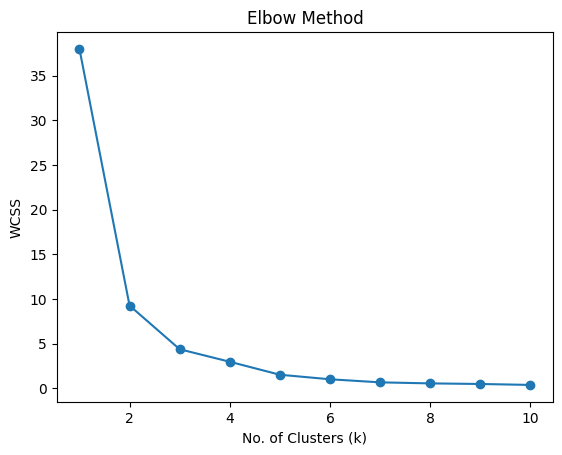

   Hours  Marks  Cluster
0    1.0     20        1
1    2.0     22        1
2    3.0     35        1
3    4.0     40        2
4    5.0     50        2


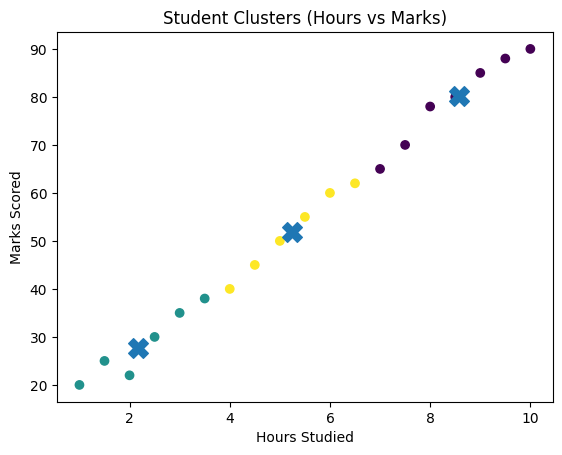

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# 1. Load dataset
df = pd.read_csv("study_marks.csv")

# 2. Select features for clustering
X = df[['Hours', 'Marks']]

# 3. Scale the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 4. Use Elbow method to find optimal k
wcss = []
for k in range(1, 11):
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_scaled)
    wcss.append(km.inertia_)

plt.plot(range(1, 11), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("No. of Clusters (k)")
plt.ylabel("WCSS")
plt.show()

# 5. Apply K-Means (choose k = 3 normally for this dataset)
kmeans = KMeans(n_clusters=3, random_state=42)
df['Cluster'] = kmeans.fit_predict(X_scaled)

print(df.head())

# 6. Plot clusters
plt.scatter(df['Hours'], df['Marks'], c=df['Cluster'])
plt.scatter(kmeans.cluster_centers_[:, 0]*X['Hours'].std()+X['Hours'].mean(),
            kmeans.cluster_centers_[:, 1]*X['Marks'].std()+X['Marks'].mean(),
            marker='X', s=200)
plt.xlabel("Hours Studied")
plt.ylabel("Marks Scored")
plt.title("Student Clusters (Hours vs Marks)")
plt.show()
